In [1]:
import sys
import importlib
def reload_modules(*modules):
    for module in modules:
        if module.__name__ in sys.modules:
            importlib.reload(module)
        else:
            print(f"Module {module.__name__} is not currently imported.")

import numpy as np
import time
import copy
from PIL import Image
import cv2
import open3d as o3d
import ast
import importlib
import imutils
import matplotlib.pyplot as plt
# reload_modules(pcd, utils, real, ur5, gripper, control_utils)
from magpie_perception import pcd
from magpie_perception import utils
from magpie_perception.utils import label_wrist_image, find_object, label_wrist_image_rotation_axes, optimize_and_correct_frame, plot_frames_3d
from magpie_control import realsense_wrapper as real
from magpie_control import ur5
from magpie_control import gripper
from magpie_control import poses
from magpie_control import utils as control_utils
import spatialmath as sm
reload_modules(pcd, utils, real, ur5, gripper, control_utils)
from magpie_control.utils import transform_6d

# rerun viz
# import rerun as rr
# from rerun_rlds_ur5.rlds import RLDSDataset, DeliGraspTrajectory, LiveRobotData
# from rerun_rlds_ur5.rerun_loader_urdf import URDFLogger, get_urdf_paths, update_urdf
# reload_modules(LiveRobotData, URDFLogger)
# ur5_urdf, _, _= get_urdf_paths("ur5")
# rr.init("ScalingForce-visualized", spawn=True)
# urdf_logger = URDFLogger(ur5_urdf)
# urdf_logger.log()
# rr.log("annotation", rr.TextDocument("annotation_1",media_type="text/markdown"))
# viz_joints = False
# rerun_viz = LiveRobotData(entity_to_transform=urdf_logger.entity_to_transform, visualize_joints=viz_joints)
# rr.send_blueprint(rerun_viz.blueprint())
rerun_viz = None
# with help from: https://github.com/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb
import os
from google import genai
import openai
from dotenv import load_dotenv
import instructor
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection, sf_position_thinker
from magpie_prompts import conversation
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
reload_modules(sf_force_thinker, sf_grasp_selection, sf_position_thinker, conversation, sf_force_reflection)

load_dotenv()
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
OPENAI_API_KEY = os.getenv('CORRELL_API_KEY')
GEMINI_MODEL_ID = "gemini-2.0-flash" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-pro-exp-03-25"] {"allow-input":true}
# OPENAI_MODEL_ID = "gpt-4o-mini"
OPENAI_MODEL_ID = "gpt-4.1-mini"

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)
force_thinker = sf_force_thinker.PromptForceThinker()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.


In [1]:
# from magpie_perception.label import Label
# from magpie_perception.label_owlvit import LabelOWLViT
# from magpie_perception.label_owlv2  import LabelOWLv2
# from magpie_perception.label_dino   import LabelDINO
# from magpie_perception.mask_sam2    import MaskSAM2

# label_models = {'owl-vit': LabelOWLViT(),
#                 'owl-v2':  LabelOWLv2(),
#                 'dino':    LabelDINO(),}
# mask_models = {'mask': MaskSAM2(),
#                'box-dbscan': None}
# label_model = label_models['owl-vit']
# label_model = label_models['owl-v2']
# label_model.init()

/home/will/miniconda3/envs/octo/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


KeyboardInterrupt: 

In [2]:
devices = real.poll_devices()
print(devices)
wrist = real.RealSense(fps=15, w=640, h=480, device_name="D405")
wrist.initConnection(device_serial=devices['D405'])
wkspc = real.RealSense(zMax=5, fps=6, w=640, h=480, device_name="D435")
wkspc.initConnection(device_serial=devices['D435'])

{'D435': '832412070344', 'D405': '126122270157'}
There are 2 available devices!
There are 2 available devices!


# Grasp Localization and Initial Motion

In [127]:
config = "3w_fa"
# wkspc_cam_config = "chair"
wkspc_cam_config = "table"
# wkspc_cam_config = "ego"
# user_query = "push the wheeled chair into the table"
# user_query = "turn the wheeled chair to the left of the table"
# grasp_phrase = "back of the chair"
user_query = "push the bottle forward 10cm"
# user_query = "push the bottle to the green duck"
# user_query = "tip the bottle over onto its front side"
grasp_phrase = "the middle of the bottle"
# user_query = "open the blue case"
# user_query = "close the blue case"
# grasp_phrase = "blue case top handle"
model_type = "gemini"
# model_type = "openai"
client, model = None, None
if model_type == "openai":
    client = openai_client
    model = "gpt-4.1-mini"
    # model = OPENAI_MODEL_ID
elif model_type == "gemini":
    client = gemini_client
    model = GEMINI_MODEL_ID
pre_rotation = sm.SO3.Rz(np.pi).A
origin=None

rotate_wrist_in_wkspc = True
tile_img = True
# SAVE = False
SAVE = True
STEP = 0
log_time = time.time()
LOAD = False
if not LOAD:
    LOG_NAME = f"scalingforce/0_experiments/{config}/{user_query}/{log_time}"
else:
    LOG_NAME = f"scalingforce/tip the bottle onto its edge_log_1744833659.8022175"
    episode_name = f"{LOG_NAME}/episode_0_1744834691.0252757"
if not os.path.exists(LOG_NAME) and SAVE:
    os.makedirs(LOG_NAME)
MESSAGES, RESPONSES, MOTION_PLANS, MOTION_REPORTS, CONVERSATION, CONVERSATION_IMAGES = [], [], [], [], [], []

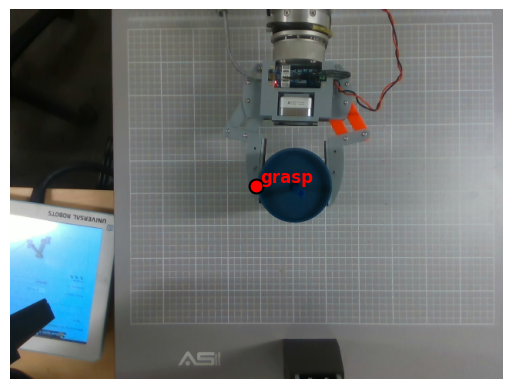

In [128]:
pcd_wrist, rgbd_wrist = wrist.getPCD()
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()

img_wrist = np.array(rgbd_wrist.color).copy()
img_wkspc = np.array(rgbd_wkspc.color)
H0, W0 = img_wkspc.shape[:2]
img = Image.fromarray(img_wkspc).copy()
W1 = 800
H1 = int(800 * H0 / W0)
# img = Image.fromarray(img_wrist)

img = img.resize((W1, H1), Image.Resampling.LANCZOS)
img_wkspc_resized = imutils.resize(img_wkspc, width=1000)


grasp_prompt = sf_grasp_selection.grasp_prompt
image_response = gemini_client.models.generate_content(
    model=GEMINI_MODEL_ID,
    contents=[grasp_prompt, f"task: {user_query} grasp phrase: {grasp_phrase}", img],
)
grasp_selection = ast.literal_eval(image_response.text.split("\n")[1])
# grasp_selection = ast.literal_eval(image_response.text)
point = grasp_selection['point']
y_norm, x_norm = point

# Step 1: [0, 1000] → resized pixel coordinates
y_px = (y_norm / 1000) * H1
x_px = (x_norm / 1000) * W1
# Step 2: resized pixels → original pixels
scale_x = W0 / W1
scale_y = H0 / H1
x_orig = x_px * scale_x
y_orig = y_px * scale_y
def plot_point_on_image(img, x, y, label="grasp", color='red'):
    plt.imshow(img)
    plt.scatter([x], [y], c=color, s=100, marker='o', edgecolors='black', linewidths=1.5)
    plt.text(x + 5, y - 5, label, color=color, fontsize=12, weight='bold')
    plt.axis('off')
    plt.show()

origin = (x_orig, y_orig)
plot_point_on_image(img_wkspc, x_orig, y_orig, label="grasp")

In [ ]:
# query = [grasp_phrase]
# seg_type = 'box-dbscan'
# mask_model = mask_models[seg_type]
# pcd_wrist, rgbd_wrist = wrist.getPCD()
# pose, pred_image = find_object(rgbd_wrist, query, label_model, mask_model, seg_type, wrist)
# np.save(f"{LOG_NAME}/init_moveto_pose.npy", pose)
# print(pose)
# print(plt.get_backend())
# %matplotlib inline
# plt.imshow(pred_image)
# plt.axis('off')  # Optional: to hide axis values and ticks
# plt.show()

In [123]:
ROBOT_IP = "192.168.0.4"
robot = ur5.UR5_Interface(ROBOT_IP, 
                            freq=6, # 6Hz frequency
                            record=False,
                            provide_gripper=True,
                            provide_ft_sensor=True,)
robot.start()
robot.start_ft_sensor()
# robot.moveL_translation_tooltip(pose, z_offset=0.03, asynch=False)
G = robot.gripper


Found Dynamixel Port:
/dev/ttyACM1

Succeeded to open the port
Succeeded to change the baudrate


# Physical Reasoning for Forceful Motion Plan

In [129]:
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()
pcd_wrist, rgbd_wrist = wrist.getPCD()
img_wrist = np.array(rgbd_wrist.color)
img_wkspc = np.array(rgbd_wkspc.color)
reload_modules(sf_force_thinker, sf_grasp_selection, sf_position_thinker, conversation, sf_force_reflection)
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
from magpie_prompts.prompts import sf_force_thinker

R_cw = np.array([ # camera to wrist, rotate pi/2 about Z
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
R_wkspc_table = sm.SO3.Rx(np.pi).A
R_wkspc_chair = sm.SO3.Rx(np.pi).A @ sm.SO3.Rx(-np.pi/2).A @ sm.SO3.Rz(np.pi/4).A
# R_wkspc_ego = sm.SO3.Rx(np.pi).A @ sm.SO3.Rx(-np.pi/2).A @ sm.SO3.Rx(15, unit='deg').A# no transformation
R_wkspc_ego = sm.SO3.Rx(np.pi/2).A @ sm.SO3.Rz(0, unit='deg').A @ sm.SO3.Rx(10, unit='deg').A
R_wkspc_ego = sm.SO3.Rz(0).A
R_wkspc_ego = sm.SO3.Rx(np.pi/2).A
R_wkspc_ego = sm.SO3.Rx(np.pi/2).A @ sm.SO3.Rx(15, unit='deg').A
wkspc_config = {"chair": R_wkspc_chair, "table": R_wkspc_table, "ego": R_wkspc_ego}
R_wkspc = wkspc_config[wkspc_cam_config]
T_wr = np.array(robot.getPose())
T_init = T_wr.copy()
R_wr = T_wr[:3, :3]
R_corrected, R_c = optimize_and_correct_frame(R_wr.copy())
R_cr = R_cw @ R_wr.T
if "wb" in config or "3b" in config:
    R_cr = R_cw @ R_wr.T @ pre_rotation
    R_wkspc = R_wkspc @ pre_rotation
vlm_R_wrist = R_c @ pre_rotation
wrist_pre_rotation = sm.SO3.Rz(-np.pi/2).A
wrist_pre_rotation = sm.SO3.Rz(np.pi/2).A
if rotate_wrist_in_wkspc:
    c_R_wkspc = R_wkspc @ R_corrected @ pre_rotation
    # ego
    # c_R_wkspc = R_wkspc @ R_corrected
    # c_R_wkspc = R_wkspc @ R_corrected @ sm.SO3.Ry(15, unit='deg').A
    # c_R_wkspc = R_wkspc @ R_corrected @ sm.SO3.Ry(5, unit='deg').A @ sm.SO3.Rx(0, unit='deg').A
    # c_R_wkspc = R_wkspc @ R_corrected @ sm.SO3.Ry(15, unit='deg').A @ sm.SO3.Rx(0, unit='deg').A 
else:
    wrist_rot = sm.SO3.Rz(np.pi/2).A
    c_R_wkspc = R_wkspc @ R_cr.T @ wrist_rot # I don't know why this works
    # ego
    # c_R_wkspc = R_wkspc @ R_cr.T @ wrist_rot @ sm.SO3.Rx(np.pi).A
    # c_R_wkspc = R_wkspc @ R_cr.T
    # c_R_wkspc = R_wkspc @ R_cr.T @ sm.SO3.Ry(np.pi).A @ sm.SO3.Rz(-np.pi/2).A
    # c_R_wkspc = R_wkspc @ R_wr
    # c_R_wkspc = R_wkspc @ R_wr @ sm.SO3.Ry(np.pi).A @ sm.SO3.Rz(np.pi).A



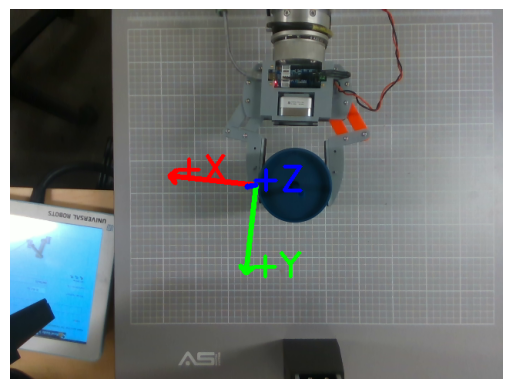

In [130]:
intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
wkspc_intrinsics = np.load("scalingforce/wkspc_intrinsics_matrix.npy", allow_pickle=True)
# ww = label_wrist_image_rotation_axes(img_wrist.copy(), R_cw, intrinsics, axis_length=0.03)
ww = label_wrist_image_rotation_axes(img_wrist.copy(), wrist_pre_rotation, intrinsics, axis_length=0.03)
ww_save = ww.copy()
if not tile_img: ww = [("this is the wrist frame labelled on the wrist view", ww)]
ww_save_unlabeled = img_wrist.copy()

wb = label_wrist_image_rotation_axes(img_wrist.copy(), R_cr, intrinsics, axis_length=0.03)
wb_save = wb.copy()
if not tile_img: wb = [("this is the base frame labelled on the wrist view", wb)]
wb_save_unlabeled = img_wrist.copy()

wkspc_b = label_wrist_image_rotation_axes(img_wkspc.copy(), R_wkspc, wkspc_intrinsics, axis_length=0.03, origin=origin)
wkspc_b_save = wkspc_b.copy()
if not tile_img: wkspc_b = [("this is the base frame labelled on the workspace view", wkspc_b)]
wkspc_b_save_unlabeled = img_wkspc.copy()

wkspc_w = label_wrist_image_rotation_axes(img_wkspc.copy(), c_R_wkspc, wkspc_intrinsics, axis_length=0.03, origin=origin)
wkspc_w_save = wkspc_w.copy()
if not tile_img: wkspc_w = [("this is the wrist frame labelled on the workspace view", wkspc_w)]
wkspc_w_save_unlabeled = img_wkspc.copy()

wkspc_w_b = np.hstack((wkspc_b, wkspc_w))

wb_3b = np.hstack((wb, wkspc_b))
if not tile_img: wb_3b = [("this is the base frame labelled on the wrist view", wb), ("this is the base frame labelled on the workspace view", wkspc_b)]
wb_3b_save = np.hstack((wb, wkspc_b))
wb_3b_save_unlabeled = np.hstack((img_wrist, img_wkspc))

ww_wb = np.hstack((wb, ww))
if not tile_img: ww_wb = [("this is the base frame labelled on the wrist view", wb), ("this is the wrist frame labelled on the wrist view", ww)]
ww_wb_save = np.hstack((wb, ww))
ww_wb_save_unlabeled = np.hstack((img_wrist, img_wrist))

ww_wb_3b = np.hstack((wb, wkspc_b, ww))
if not tile_img: ww_wb_3b = [("this is the base frame labelled on the wrist view", wb), ("this is the wrist frame labelled on the workspace view", wkspc_b), ("this is the wrist frame labelled on the wrist view", ww)]
ww_wb_3b_save = np.hstack((wb, wkspc_b, ww))
ww_wb_3b_save_unlabeled = np.hstack((img_wrist, img_wkspc, img_wrist))

ww_wb = np.hstack((wb, ww))
if not tile_img: ww_wb = [("this is the base frame labelled on the wrist view", wb), ("this is the wrist frame labelled on the wrist view", ww)]
ww_wb_save = np.hstack((wb, ww))
ww_wb_save_unlabeled = np.hstack((img_wrist, img_wrist))

ww_3w = np.hstack((wkspc_w, ww))
if not tile_img: ww_3w = [("this is the wrist frame labelled on the workspace view", wkspc_w), ("this is the wrist frame labelled on the wrist view", ww)]
ww_3w_save = np.hstack((wkspc_w, ww))
ww_3w_save_unlabeled = np.hstack((img_wkspc, img_wrist))

world_chair_reference = 'As ground truth reference, "forward" motion in the world corresponds to motion toward the workspace camera view, "upward" motion in the world corresponds to motion up from the workspace camera view image, and "right" motion in the world corresponds to motion to the left of the workspace camera view image.'
world_chair_reference = ""
world_table_reference = 'As ground truth reference for world motion relative to the robot, "forward" motion in the world corresponds to motion down the workspace camera view image, "upward" and "downward" motion in the world corresponds to motion out of and into, respectively, the the workspace camera view image, and "right" motion in the world corresponds to motion to the left of the workspace camera view image. '
world_ego_reference = '''
As ground truth reference for world motion relative to the robot, the workspace camera view roughly corresponds to canonical motion in the world. 
Upward motion in the world corresponds to motion up workspace camera view image, 
right-ward motion in the world corresponds to motion to the right of the workspace camera view image, 
and forward motion in the world corresponds to motion into the workspace camera view image.
The wrist frame axes will roughly correspond to these directions, but will be more aligned with the gripper-object relative motion.
'''
world_reference = {"chair": world_chair_reference, "table": world_table_reference, "ego": world_ego_reference}
task_config = {
    "obj": grasp_phrase,
    "task": user_query,
    "world_reference": world_reference[wkspc_cam_config],
}
prompt_config = {
    "ww": {"image": ww, "prompt": sf_force_thinker.ww_thinker, "image_save": ww_save, "image_save_unlabeled": ww_save_unlabeled},
    "3w": {"image": wkspc_w, "prompt": sf_force_thinker.wkspc_w_thinker, "image_save": wkspc_w_save, "image_save_unlabeled": wkspc_w_save_unlabeled},
    "3w_fa": {"image": wkspc_w, "prompt": sf_force_thinker.wkspc_w_thinker, "image_save": wkspc_w_save, "image_save_unlabeled": wkspc_w_save_unlabeled},
    "3w_fa_ego": {"image": wkspc_w, "prompt": sf_force_thinker.wkspc_w_thinker, "image_save": wkspc_w_save, "image_save_unlabeled": wkspc_w_save_unlabeled},
    "ww_wb_3b": {"image": ww_wb_3b, "prompt": sf_force_thinker.ww_wb_3b_thinker, "image_save": ww_wb_3b_save, "image_save_unlabeled": ww_wb_3b_save_unlabeled},
    "ww_3w": {"image": ww_3w, "prompt": sf_force_thinker.ww_3w_thinker, "image_save": ww_3w_save, "image_save_unlabeled": ww_3w_save_unlabeled},
    "3b": {"image": wkspc_b, "prompt": sf_force_thinker.wkspc_b_thinker, "image_save": wkspc_b_save, "image_save_unlabeled": wkspc_b_save_unlabeled},
    "wb": {"image": wb, "prompt": sf_force_thinker.wb_thinker, "image_save": wb_save, "image_save_unlabeled": wb_save_unlabeled},
    "wb_3b": {"image": wb_3b, "prompt": sf_force_thinker.wb_3b_thinker, "image_save": wb_3b_save, "image_save_unlabeled": wb_3b_save_unlabeled},
}
image = prompt_config[config]["image"]
image_save = prompt_config[config]["image_save"]
image_save_unlabeled = prompt_config[config]["image_save_unlabeled"]
prompt = prompt_config[config]["prompt"].format(**task_config)
prev_img = image_save.copy()

if SAVE:
    fn = f"{LOG_NAME}/init_axes_{user_query}.png"
    cv2.imwrite(fn, cv2.cvtColor(image_save, cv2.COLOR_RGB2BGR))
    fn = f"{LOG_NAME}/init_axes_{user_query}_unlabeled.png"
    cv2.imwrite(fn, cv2.cvtColor(image_save_unlabeled, cv2.COLOR_RGB2BGR))
    if SAVE: np.save(f"{LOG_NAME}/init_robot_pose.npy", T_init)

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(image_save)
plt.imshow(image)


In [28]:
ttl = np.array([1, 0, 5])
tta = np.array([0, 1, 0])

vlm_R_wrist = R_c @ pre_rotation
wttl = R_c @ pre_rotation @ ttl
print(wttl)
print(vlm_R_wrist @ ttl)


[-5.511e-16  1.000e+00 -5.000e+00]
[-5.511e-16  1.000e+00 -5.000e+00]


In [116]:
robot.toggle_teach_mode()

In [131]:
reload_modules(sf_force_thinker, sf_grasp_selection, sf_position_thinker, conversation, sf_force_reflection)
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
from magpie_prompts.prompts import sf_force_thinker
MESSAGES, RESPONSES, MOTION_PLANS, MOTION_REPORTS, CONVERSATION, CONVERSATION_IMAGES = [], [], [], [], [], []
if tile_img:
    img = Image.fromarray(image)
    MESSAGES = build_messages(prompt, img, messages=MESSAGES, model_type=model_type)
else:
    for i in image:
        img = Image.fromarray(i[1])
        caption = i[0]
        MESSAGES = build_messages(caption, img, messages=MESSAGES, model_type=model_type)
    MESSAGES = build_messages(prompt, image=None, messages=MESSAGES, model_type=model_type)
start = time.time()
response = send_message(client, model, MESSAGES, model_type=model_type)
end = time.time()
query_time = end - start
motion_plan = force_thinker.process_thinker_response(response)
motion_plan['query_time'] = query_time
print(response)

# Log messages

MESSAGES = build_messages(response, image=None, messages=MESSAGES, model_type=model_type, role="assistant")
RESPONSES = build_messages(response, image=None, messages=RESPONSES, model_type=model_type)
CONVERSATION = build_messages(response, image=None, messages=CONVERSATION, model_type=model_type, role="assistant")
CONVERSATION_IMAGES = build_messages(response, image=img, messages=CONVERSATION_IMAGES, model_type=model_type, role="assistant", save=True)
# Compute wrist-frame vectors
def construct_wrist_frame(plan, pose):
    if "wrist_motion_vector" in plan.keys():
        p = plan.copy()
        # undo wrist rotation if it was applied
        # R = sm.SO3.Rz(np.pi).A if rotate_wrist_in_wkspc else sm.SO3.Rz(0).A
        R = vlm_R_wrist if rotate_wrist_in_wkspc else sm.SO3.Rz(0).A
        wrench = np.array(p['wrist_wrench'])
        print(wrench)
        motion = np.array(p['wrist_motion_vector'])
        lin_new = R @ wrench[:3]
        ang_new = R @ wrench[3:]
        p['wrist_wrench'] = np.hstack((lin_new, ang_new)).round(3)
        p['wrist_motion_vector'] = R @ motion
        return p
    wrench_base = plan['ft_vector']
    wrench_wrist = transform_6d(wrench_base, pose, pose_to_origin=False, is_wrench=True, pre_rotation=pre_rotation)
    p_base = plan['world_motion_vector']
    p_wrist = R_wr.T @ p_base
    plan['wrist_motion_vector'] = p_wrist
    plan['wrist_wrench'] = wrench_wrist
    return plan
motion_plan = construct_wrist_frame(motion_plan, T_wr)
print(motion_plan)

MOTION_PLANS = build_messages(motion_plan, image=None, messages=MOTION_PLANS, model_type=model_type)

if SAVE:
    np.save(f"{LOG_NAME}/motion_response-{STEP}.npy", response, allow_pickle=True)
    np.save(f"{LOG_NAME}/motion_plan-{STEP}.npy", motion_plan, allow_pickle=True)

motion_plan

[start of motion plan]
The task is to push the bottle forward 10cm while grasping the the middle of the bottle.

Mapping World Motion to Wrist Motion:
The provided workspace image confirms that there is a blue bottle grasped by the robot gripper on a flat surface. The bottle is cylindrical and appears to be made of plastic. The task requires pushing the bottle forward 10 cm.
The labeled wrist axes correspond to the world as such: the wrist X-axis points to the left, the wrist Y-axis points downward, and the wrist Z-axis points away.
The blue axis represents wrist Z-axis motion. It roughly corresponds to motion away from the robot base. Negative motion along the Z-axis is towards the robot base.
Based off knowledge of the task and motion, in the wrist Z-axis, the object must move positively, away from the robot base, to accomplish the task.
The red axis represents wrist X-axis motion. It roughly corresponds to motion to the left in the image. Negative motion in the X-axis corresponds to

{'property_description': 'Cylindrical blue plastic bottle, mass 0.1 kg, static friction coefficient with table 0.3, static friction coefficient with gripper 0.4',
 'wrist_motion_description': 'Move the grasped bottle 10cm along the positive Z-axis of the wrist frame.',
 'wrist_motion_vector': array([ 7.499e-34, -1.000e-01, -6.123e-18]),
 'wrist_wrench': array([ 0. , -0.3, -0.1,  0. ,  0. ,  0. ]),
 'grasp_force': 7.5,
 'duration': 2.0,
 'query_time': 9.045427322387695}

In [97]:
robot.ctrl.disconnect()

In [98]:
robot.ctrl.reconnect()
robot.toggle_teach_mode()

In [107]:
robot.toggle_teach_mode()

In [114]:
STEP -= 1

In [99]:
G.reset_parameters()
G.reset_packet_overload()

In [65]:
G.reset_packet_overload()
G.reset_and_close_gripper(force_limit=15)

# Robot Motion Execution

In [132]:
importlib.reload(ur5)
importlib.reload(gripper)
robot.start_ft_sensor(poll_rate=100)
G = robot.gripper
# G.reset_parameters()
# np.save(f"{LOG_NAME}/init_home.npy", robot.home)
# pose = np.load(f"{LOG_NAME}/init_moveto_pose.npy")
G.reset_and_close_gripper(force_limit=5)
time.sleep(0.175)


[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!


In [30]:
# SAVE
if LOAD:
    motion_log['gripper'] = np.load(f"{episode_name}/gripper_log.npy", allow_pickle=True).item()
    motion_log['robot'] = np.load(f"{episode_name}/robot_log.npy", allow_pickle=True).item()
    pos_msg = np.load(f"{episode_name}/messages.npy", allow_pickle=True)
    query_image = np.load(f"{episode_name}/query_image.npy", allow_pickle=True)
    # query_image = Image.fromarray(query_image).convert("RGB")
    prev_img = query_image.copy()
    feedback_img_fn = f"{LOG_NAME}/axes_step-0_tip the bottle onto its edge.png"
    feedback_img = np.array(Image.open(feedback_img_fn))
    task_config = {
        "obj": "the top of the bottle",
        "task": "tip the bottle onto its edge",
    }
    plt.xticks([])
    plt.yticks([])
    plt.axis('off')
    plt.imshow(query_image)
    plt.imshow(feedback_img)


In [36]:
# robot.moveL_delta([0.0, 0.03, -0.1])
# robot.ctrl.speedL([0.00, -0.00, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)
# robot.ctrl.speedL([0.00, -0.00, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)
# robot.speedL_TCP([0.04, -0.00, -0.035, 0.0, 0.05, 0.0], 0.4, 0.25, tooltip=True)
# # robot.ctrl.speedL_TCP([0.00, -0.00, 0.05, 0.0, 0.0, 0.0], 0.5, 0.25)
# robot.speedL_TCP([0.05, -0.00, -0.015, 0.0, 0.05, 0.0], 0.5, 0.25, tooltip=True)

# test_vector = [0, 1, 0]
# test_wrench = [0, 0.8, 2.8, 0, 0, 0]
# test_wrench = [1.0, 0.0, -3.0, 0, 0, 0]
# test_wrench = [4.0, 0.0, -4.5, 0, 1, 0]
# test_gripper_force = 15
# test_motion_plan = {
#     "wrist_motion_vector": test_vector,
#     "wrist_wrench": test_wrench,
#     # "world_motion_vector": test_world_vector,
#     # "ft_vector": test_world_wrench,
#     "grasp_force": test_gripper_force,
#     "duration": 5.0,
# }
# SAVE = False

In [133]:
# Execute motion plan
def save_motion_log(log_name, step, motion_log):
    import time
    import os
    episode_time = time.time()
    episode_name = f"{log_name}/episode_{step}_{episode_time}"
    if not os.path.exists(episode_name):
        os.makedirs(episode_name)
    messages = [i for i in MESSAGES if type(i) == str]
    # create directory if it doesn't exist
    np.save(f"{episode_name}/prev_image.npy", prev_img, allow_pickle=True)
    np.save(f"{episode_name}/messages.npy", messages, allow_pickle=True)
    np.save(f"{episode_name}/gripper_log.npy", motion_log['gripper'],allow_pickle=True)
    np.save(f"{episode_name}/robot_log.npy", motion_log['robot'],allow_pickle=True)
    np.save(f"{episode_name}/wrist_log.npy", motion_log['record/wrist/'],allow_pickle=True)
    np.save(f"{episode_name}/wkspc_log.npy", motion_log['record/workspace/'],allow_pickle=True)
    return episode_name

import numpy as np
camera_dict = {
    wrist: "record/wrist/",
    wkspc: "record/workspace/"
}
motion_plan = np.load(f"{LOG_NAME}/motion_plan-{STEP}.npy", allow_pickle=True).item()
# motion_plan = test_motion_plan
goal_delta = np.array(motion_plan["wrist_motion_vector"])
wrench = np.array(motion_plan['wrist_wrench'])
wrench_goal = wrench * -1
# wrench_goal = wrench
init_cmd = np.hstack((wrench[:3] / 100, wrench[3:] / 15))
duration = motion_plan['duration']
grasp_force = min(motion_plan['grasp_force'], 25)
P = 0.0002 # stiffness gain, default is 0.0005
print(init_cmd)
print(wrench_goal)

robot.start_ft_sensor()
motion_log = await robot.concurrent_gripper_camera_robot_control(wrench=wrench_goal, goal_delta=goal_delta, grasp_force=grasp_force, 
                                         camera_dict=camera_dict, init_cmd=init_cmd, tolerance=-0.01, rerun_viz=rerun_viz,
                                        #  camera_dict=camera_dict, init_cmd=init_cmd, tolerance=0.00, rerun_viz=None,
                                        #  duration=duration, p=P, control_type="bang_bang")
                                         duration=duration, p=P, control_type="proportional")
robot.ctrl.speedL([0.00, -0.00, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)
STEP += 1
if SAVE: episode_name = save_motion_log(LOG_NAME, STEP, motion_log)
for key in motion_log:
    ts = motion_log[key].keys()
    last_ts = sorted(ts)[-1]
    first_ts = sorted(ts)[0]
    print(f"sensor {key} first timestamp: {first_ts}")
    print(f"sensor {key} last timestamp: {last_ts}")
    duration = last_ts - first_ts
    length = len(motion_log[key])
    print(f"sensor {key} duration: {duration}, length: {length}, Hz: {length/duration}\n")


[ 0.    -0.003 -0.001  0.     0.     0.   ]
[-0.   0.3  0.1 -0.  -0.  -0. ]
D405 Recording Started
D435 Recording Started
Error reading from OptoForce!
D405 Recording Task Cancelled
D405 Recording Stopped
D435 Recording Task Cancelled
D435 Recording Stopped
sensor gripper first timestamp: 1746817438.8977764
sensor gripper last timestamp: 1746817440.860137
sensor gripper duration: 1.9623606204986572, length: 13, Hz: 6.62467431531344

sensor robot first timestamp: 1746817438.8352146
sensor robot last timestamp: 1746817440.8535192
sensor robot duration: 2.0183045864105225, length: 98, Hz: 48.555604867493884

sensor record/wrist/ first timestamp: 1746817438.774082
sensor record/wrist/ last timestamp: 1746817440.9075873
sensor record/wrist/ duration: 2.133505344390869, length: 15, Hz: 7.030683114732298

sensor record/workspace/ first timestamp: 1746817438.589723
sensor record/workspace/ last timestamp: 1746817440.7611492
sensor record/workspace/ duration: 2.1714260578155518, length: 14, Hz:

# Feedback

first_pose=array([-0.224, -0.485,  0.18 , -0.213, -2.248,  2.151]), last_pose=array([-0.223, -0.48 ,  0.181, -0.213, -2.248,  2.151])
Task: push the bottle forward 10cm while grasping the middle of the bottle
Human Feedback: 
Motion Plan Results: 
Distance traveled relative to original wrist base frame [x, y, z] (m) axes: [-0.    -0.002  0.005]
Distance traveled along base frame [x, y, z] (m) axes since prior motion: [-0.001 -0.005  0.002]

6D Base Frame Wrench [x, y, z, rx, ry, rz] (N and Nm) Log Summary:
Motion Duration: 2.0183045864105225s
Average base_wrench Downsampled at 2Hz:
0.0s to 0.5: [-0.04  0.28 -0.    0.01  0.01  0.02]
0.5s to 1.0: [ 0.12  0.08  1.02  0.11 -0.02  0.01]
1.0s to 1.5: [ 0.04  0.2   1.52  0.17 -0.03  0.02]
1.5s to 2.0: [ 0.02 -0.1   1.28  0.14 -0.03  0.03]
2.0s to 2.5: [-0.63  1.92  0.78  0.09 -0.02  0.09]
Overall Average Across Episode: [-0.1   0.48  0.92  0.1  -0.02  0.03]

6D Wrist Frame Wrench [x, y, z, rx, ry, rz] (N and Nm) Log Summary:
Motion Duration: 

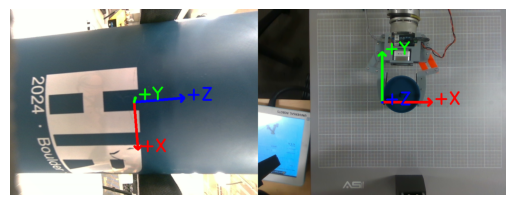

In [134]:
# Generate System Feedback and Motion Report
gripper_log  = motion_log['gripper'].copy()
robot_log    = motion_log['robot'].copy()
gripper_ts   = sorted(gripper_log.keys())
robot_ts     = sorted(robot_log.keys())

wrist_log    = motion_log['record/wrist/']
wkspc_log    = motion_log['record/workspace/']
wrist_ts     = sorted(wrist_log.keys())
wkspc_ts     = sorted(wkspc_log.keys())

R_cw = np.array([ # camera to wrist
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
T_wr = np.array(sm.SE3(poses.pose_vec_to_mtrx(np.array(robot_log[robot_ts[-1]]['actual_TCP_pose']))))
R_wr = T_wr[:3, :3]
R_cr = R_cw @ R_wr.T @ pre_rotation
intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
img_wrist_final = wrist_log[wrist_ts[-1]]['rgb']
img_wkspc_final = wkspc_log[wkspc_ts[-1]]['rgb']
img_wrist_final_labeled = label_wrist_image_rotation_axes(img_wrist_final.copy(), R_cw, intrinsics, axis_length=0.03)
img_wrist_final_labeled_base = label_wrist_image_rotation_axes(img_wrist_final.copy(), R_cr, intrinsics, axis_length=0.03)
img_wkspc_final_labeled = label_wrist_image_rotation_axes(img_wkspc_final.copy(), R_wkspc, intrinsics, axis_length=0.03)
feedback_position_img = np.hstack((img_wrist_final_labeled_base, img_wkspc_final_labeled))
feedback_img = np.hstack((img_wrist_final_labeled_base, img_wkspc_final_labeled))

# save img
np.save(f"{episode_name}/feedback_image.npy", feedback_img, allow_pickle=True)
fn = f"{episode_name}/feedback_image.png"
cv2.imwrite(fn, cv2.cvtColor(feedback_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(feedback_img)

from spatialmath.base import rodrigues, tr2rpy
import numpy as np
human_feedback = ""
motion_report = ""
motion_report += f"Task: {user_query} while grasping {grasp_phrase}\n"
motion_report += f"Human Feedback: {human_feedback}\n"
# motion_report += f"Initial Motion Plan: {motion_plan}\n"
# get first and last TCP pose of robot log
first_pose = np.array(robot_log[robot_ts[0]]['actual_TCP_pose'])
last_pose =  np.array(robot_log[robot_ts[-1]]['actual_TCP_pose'])
print(f"{first_pose=}, {last_pose=}")
dist =  (last_pose - first_pose)[:3] @ pre_rotation
# get the rotation matrix from the wrist frame to the robot frame
rot = rodrigues(first_pose[3:6])
# transform distance to be relative to the first TCP wrist frame, use inverse of rot
dist_wrist = rot.T @ dist[:3]
motion_report += f"Motion Plan Results: \nDistance traveled relative to original wrist base frame [x, y, z] (m) axes: {dist_wrist.round(3)}\n"
motion_report += f"Distance traveled along base frame [x, y, z] (m) axes since prior motion: {dist[:3].round(3)}\n"
init_pose = np.load(f"{LOG_NAME}/init_robot_pose.npy", allow_pickle=True)
original_dist = (last_pose[:3] - T_init[:3, 3]) @ pre_rotation
# motion_report += f"Distance traveled along base frame [x, y, z] (m) axes since starting position: {original_dist[:3].round(3)}\n"

# Use a simple moving average with a window size of downsample_factor
def moving_average(data, window_size):
    return np.array([np.mean(data[i:i+window_size], axis=0) for i in range(0, len(data), window_size)])

def get_report(desired_freq, timestamps, log, name, description):
    log_dur = timestamps[-1] - timestamps[0]
    log_flat = np.array([log[i][name] for i in timestamps])
    num_downsampled_entries = int(log_dur // (1 / desired_freq))
    downsample_factor = len(timestamps) // num_downsampled_entries
    downsampled_log = moving_average(log_flat, downsample_factor)
    summary = f"\n{description} Log Summary:"
    summary += f"\nMotion Duration: {log_dur}s"
    summary += f"\nAverage {name} Downsampled at {desired_freq}Hz:"
    for i, entry in enumerate(downsampled_log):
        summary += f"\n{i*(1/desired_freq)}s to {(i+1)*(1/desired_freq)}: {entry.round(2)}"
    summary += f"\nOverall Average Across Episode: {np.mean(downsampled_log, axis=0).round(2)}"
    return summary
desired_freq = 2

# flip the sign of all the wrenches because LLMs do not understand action/reaction
for i in robot_ts:
    wrench = np.array(robot_log[i]['wrench'])
    T = sm.SE3(poses.pose_vec_to_mtrx(np.array(robot_log[i]['actual_TCP_pose']))).A
    pre_rot = sm.SO3.Rz(-np.pi).A
    base_wrench = transform_6d(wrench, T, pose_to_origin=True, is_wrench=True, pre_rotation=pre_rot)
    robot_log[i]['base_wrench'] = -1 * base_wrench
    robot_log[i]['wrench'] = -1 * wrench

base_wrench_report = get_report(desired_freq, robot_ts, robot_log, "base_wrench", "6D Base Frame Wrench [x, y, z, rx, ry, rz] (N and Nm)")
motion_report += f"{base_wrench_report}\n"

wrench_report = get_report(desired_freq, robot_ts, robot_log, "wrench", "6D Wrist Frame Wrench [x, y, z, rx, ry, rz] (N and Nm)")
motion_report += f"{wrench_report}\n"

gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf", "Gripper Contact Force (N)")
# gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf_l", "Left Gripper Contact Force (N)")
motion_report += f"{gripper_report}\n"
# gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf_r", "Right Gripper Contact Force (N)")
# print(gripper_report)
# motion_report += f"{gripper_report}\n"
print(motion_report)
if SAVE:
    with open(f"{episode_name}/motion_report.txt", "w") as f:
        f.write(motion_report)
    np.save(f"{episode_name}/motion_report.npy", motion_report, allow_pickle=True)



In [97]:
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection, sf_position_thinker
from magpie_prompts import conversation
reload_modules(sf_force_thinker, sf_grasp_selection, sf_position_thinker, conversation, sf_force_reflection)
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message


feedback_task_config = task_config.copy()
# feedback_task_config['motion_report'] = motion_report
# feedback_task_config['human_feedback'] = human_feedback
feedback_prompt = sf_force_reflection.prompt_base_frame_reflector.format(**feedback_task_config)
if STEP == 1:
    CONVERSATION = build_messages(feedback_prompt, None, messages=CONVERSATION, model_type=model_type)
    CONVERSATION_IMAGES = build_messages(feedback_prompt, None, messages=CONVERSATION_IMAGES, model_type=model_type)

# feedback_messages = MOTION_REPORTS.copy()
feedback_messages = CONVERSATION.copy() # copy the text-only conversation, add before and after images
MOTION_REPORTS = build_messages(motion_report, image=None, messages=MOTION_REPORTS, model_type=model_type)
img_feedback_PIL = Image.fromarray(feedback_img).convert("RGB")
img_previous_PIL = Image.fromarray(prev_img).convert("RGB")
prev_img = feedback_img

MESSAGES = build_messages(feedback_prompt, img_feedback_PIL, messages=MESSAGES, model_type=model_type)
feedback_messages = build_messages("This is the previous image, taken prior to execution of the robot motion plan", 
                                   img_previous_PIL, messages=feedback_messages, model_type=model_type)
# feedback_messages = build_messages(feedback_prompt, img_feedback_PIL, messages=feedback_messages, model_type=model_type)
feedback_messages = build_messages(motion_report, img_feedback_PIL, messages=feedback_messages, model_type=model_type)
feedback_response = send_message(client, model, feedback_messages, model_type=model_type)
MESSAGES = build_messages(feedback_response, image=None, messages=MESSAGES, model_type=model_type, role="assistant")
RESPONSES = build_messages(feedback_response, image=None, messages=RESPONSES, model_type=model_type)

# building the conversation
CONVERSATION = build_messages(motion_report, image=None, messages=CONVERSATION, model_type=model_type)
CONVERSATION = build_messages(feedback_response, image=None, messages=CONVERSATION, model_type=model_type, role="assistant")
CONVERSATION_IMAGES = build_messages("This is the previous image, taken prior to execution of the robot motion plan", 
                                   img_previous_PIL, messages=CONVERSATION_IMAGES, model_type=model_type, save=True)
CONVERSATION_IMAGES = build_messages(motion_report, img_feedback_PIL, messages=CONVERSATION_IMAGES, model_type=model_type, save=True)
CONVERSATION_IMAGES = build_messages(feedback_response, image=None, messages=CONVERSATION_IMAGES, model_type=model_type, role="assistant", save=True)

print(feedback_response)
force_reflector = sf_force_reflection.PromptForceReflection()
motion_feedback_plan = force_reflector.process_thinker_response(feedback_response)
motion_feedback_plan = construct_wrist_frame(motion_feedback_plan, robot.getPose().A)
MOTION_PLANS = build_messages(motion_feedback_plan, image=None, messages=MOTION_PLANS, model_type=model_type)
# save conversation
if SAVE:
    np.save(f"{LOG_NAME}/response-{STEP}.npy", feedback_response, allow_pickle=True)
    np.save(f"{LOG_NAME}/motion_plan-{STEP}.npy", motion_feedback_plan, allow_pickle=True)
    np.save(f"{LOG_NAME}/conversation-{STEP}.npy", CONVERSATION, allow_pickle=True)
    # np.save(f"{LOG_NAME}/conversation_images.npy", CONVERSATION_IMAGES, allow_pickle=True)
motion_feedback_plan


KeyboardInterrupt: 

In [243]:
CONVERSATION

['[start of motion plan]\nThe task is to push the bottle forward while grasping the .\n\nUnderstanding Object-Centric Motion in the World Frame:\nThe provided images in the two-part image confirm the presence of a cylindrical bottle and a robot gripper on a flat surface. The bottle appears to be made of a somewhat rigid plastic, and the robot gripper appears to be metallic.\nThe red axis representing the world Z-axis corresponds to upward (positive) and downward (negative) motion in the world. \nTo complete the task, the object in the image should have no linear motion along the Z-axis with magnitude 0.0 meters.\nThe green axis representing the world X-axis corresponds to right (positive) and left (negative) motion in the world, relative to the robot. \nTo complete the task, the object in the image should have no linear motion along the X-axis with magnitude 0.0 meters.\nThe blue axis representing the world Y-axis corresponds to forward (positive) and backward (negative) motion in the 